In [3]:
import pandas as pd

# Load dataset
IssueReturn = pd.read_csv("IssueReturn_Dataset.csv")

# Print shape
print("IssueReturn shape:", IssueReturn.shape)

IssueReturn shape: (201, 20)


In [4]:
# --- Count duplicates ---
num_dupes = IssueReturn.duplicated().sum()
print(f"Number of duplicate rows: {num_dupes}")

# --- Count missing values per column ---
missing_counts = IssueReturn.isnull().sum()

# --- Show only columns with missing values ---
missing_summary = missing_counts[missing_counts > 0]
print("\nColumns with missing values and their counts:")
print(missing_summary)

Number of duplicate rows: 1

Columns with missing values and their counts:
Return_Date              47
Issue_Status              1
Number_of_Days_Issued     2
Renew_Count               1
Fine_Amount               3
Total_Library_Visits      1
dtype: int64


In [17]:
import pandas as pd

# --- Load dataset ---
IssueReturn = pd.read_csv("IssueReturn_Dataset.csv")

# --- Remove duplicates ---
IssueReturn_clean = IssueReturn.drop_duplicates()

# --- Fill missing values: "NULL" for text, 0 for numbers ---
IssueReturn_clean = IssueReturn_clean.fillna({
   # 'Return_Date': "NULL",
    'Issue_Status': "NULL",
    'Number_of_Days_Issued': 0,
    'Renew_Count': 0,
    'Fine_Amount': 0,
    'Library_Visit_Frequency': 0,
    'Total_Library_Visits': 0,
    'Reading_Duration_Hours': 0,
    'Preferred_Book_Type': "NULL",
    'Online_Resource_Usage': "NULL",
    'Late_Return_Count': 0,
    'Transaction_Mode': "NULL",
    'Feedback_Rating': 0
})



# Convert Issue_Date, Due_Date, Return_Date to datetime
for col in ["Issue_Date", "Due_Date", "Return_Date"]:
    IssueReturn_clean[col] = pd.to_datetime(
        IssueReturn_clean[col].replace("NULL", pd.NA), 
        errors="coerce", 
        dayfirst=True
    )


# --- Print summary ---
print("IssueReturn cleaned shape:", IssueReturn_clean.shape)
print("Missing values after cleaning:\n", IssueReturn_clean.isnull().sum())

print("✅ Dates converted to datetime format")
print(IssueReturn_clean[["Issue_Date","Due_Date","Return_Date"]].head())
# --- Save cleaned dataset ---
IssueReturn_clean.to_csv("IssueReturn_Dataset_Clean.csv", index=False)
print("\nCleaned dataset saved as 'IssueReturn_Dataset_Clean.csv'")

IssueReturn cleaned shape: (200, 20)
Missing values after cleaning:
 Issue_ID                    0
Student_ID                  0
Book_ID                     0
Issue_Date                  0
Due_Date                    0
Return_Date                46
Issue_Status                0
Number_of_Days_Issued       0
Renew_Count                 0
Fine_Amount                 0
Library_Visit_Frequency     0
Total_Library_Visits        0
Reading_Duration_Hours      0
Preferred_Book_Type         0
Online_Resource_Usage       0
Late_Return_Count           0
Librarian_ID                0
Library_Shift               0
Transaction_Mode            0
Feedback_Rating             0
dtype: int64
✅ Dates converted to datetime format
  Issue_Date   Due_Date Return_Date
0 2025-01-29 2025-02-12  2025-02-18
1 2025-09-23 2025-10-07  2025-10-07
2 2025-06-12 2025-06-26  2025-06-22
3 2025-02-10 2025-02-24  2025-02-23
4 2025-10-18 2025-11-01  2025-10-30

Cleaned dataset saved as 'IssueReturn_Dataset_Clean.csv'


=== BEFORE CLEANING ===
Rows: 201
Duplicate rows: 1
Missing values per column:
Return_Date              47
Issue_Status              1
Number_of_Days_Issued     2
Renew_Count               1
Fine_Amount               3
Total_Library_Visits      1
dtype: int64

=== AFTER CLEANING ===
Rows: 200
Duplicate rows: 0
Missing values per column:
Series([], dtype: int64)


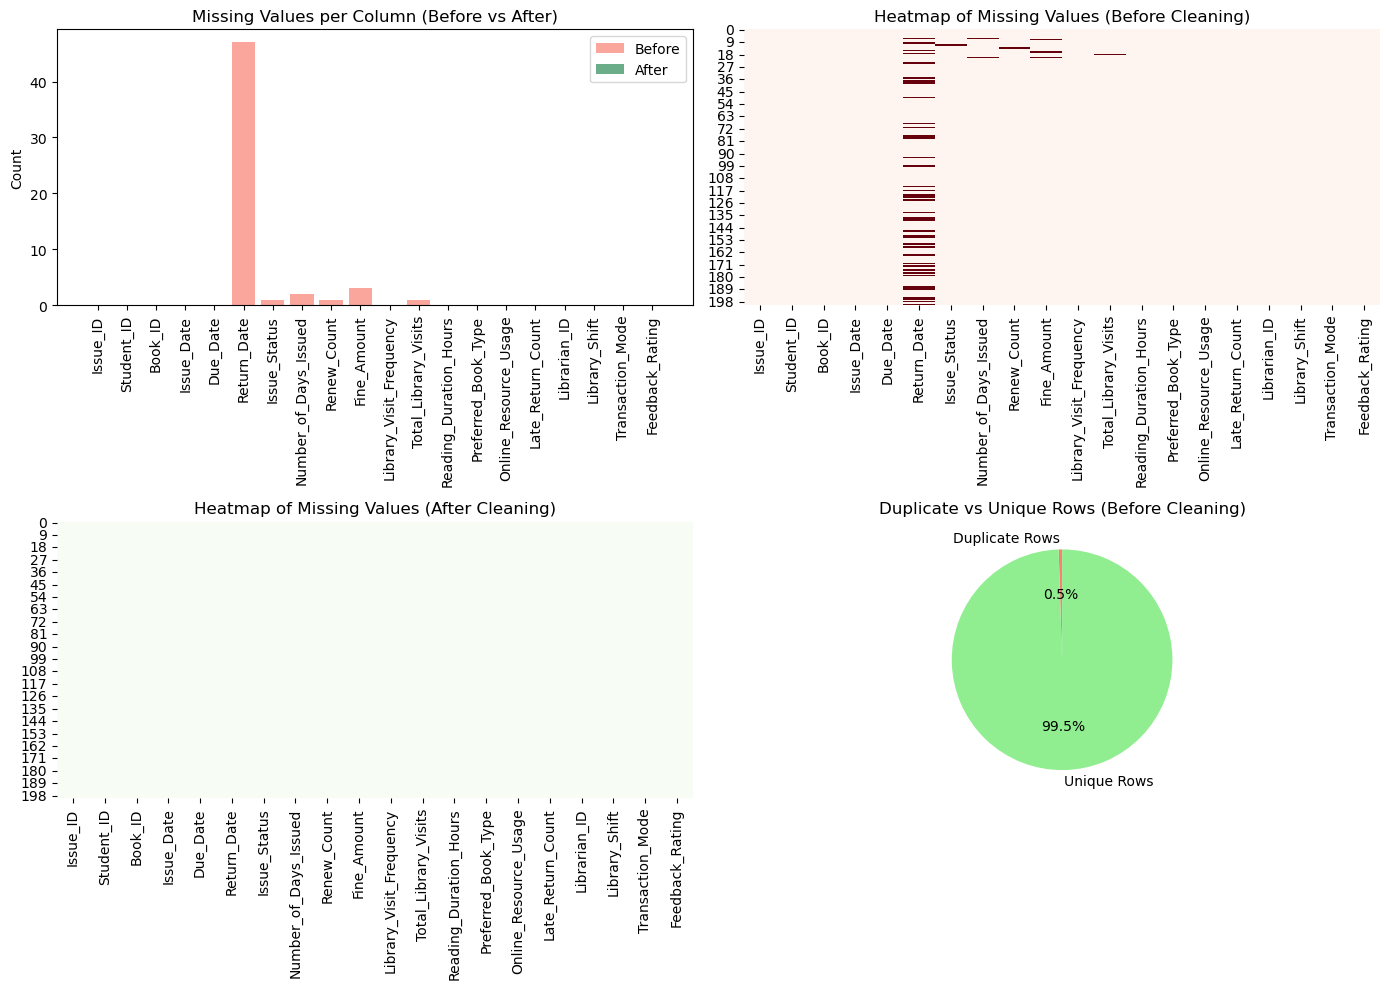

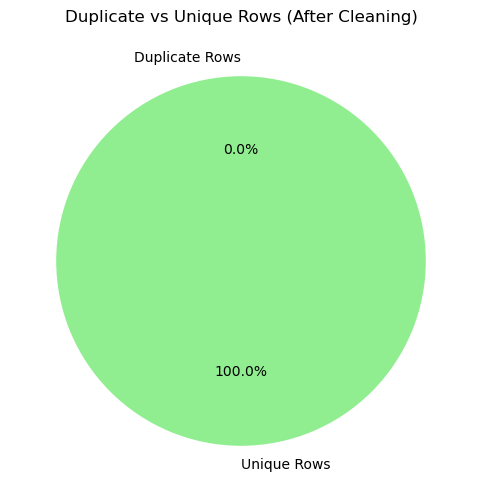


Cleaned dataset saved as 'IssueReturn_Dataset_Clean.csv'


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load dataset ---
library = pd.read_csv("IssueReturn_Dataset.csv")

# --- Before Cleaning Summary ---
print("=== BEFORE CLEANING ===")
print(f"Rows: {library.shape[0]}")
print(f"Duplicate rows: {library.duplicated().sum()}")
print("Missing values per column:")
print(library.isnull().sum()[library.isnull().sum() > 0])

# --- Clean dataset ---
library_clean = library.drop_duplicates().fillna({
    'Return_Date': "NULL",
    'Issue_Status': "NULL",
    'Number_of_Days_Issued': 0,
    'Renew_Count': 0,
    'Fine_Amount': 0,
    'Library_Visit_Frequency': 0,
    'Total_Library_Visits': 0,
    'Reading_Duration_Hours': 0,
    'Preferred_Book_Type': "NULL",
    'Online_Resource_Usage': "NULL",
    'Late_Return_Count': 0,
    'Transaction_Mode': "NULL",
    'Feedback_Rating': 0
})

# --- After Cleaning Summary ---
print("\n=== AFTER CLEANING ===")
print(f"Rows: {library_clean.shape[0]}")
print(f"Duplicate rows: {library_clean.duplicated().sum()}")
print("Missing values per column:")
print(library_clean.isnull().sum()[library_clean.isnull().sum() > 0])

# -----------------------------
# Visualization Dashboard
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Missing values per column (Before vs After)
missing_before = library.isnull().sum()
missing_after = library_clean.isnull().sum()

axes[0,0].bar(missing_before.index, missing_before.values, color="salmon", alpha=0.7, label="Before")
axes[0,0].bar(missing_after.index, missing_after.values, color="seagreen", alpha=0.7, label="After")
axes[0,0].set_title("Missing Values per Column (Before vs After)")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis='x', rotation=90)
axes[0,0].legend()

# 2. Heatmap Before Cleaning
sns.heatmap(library.isnull(), cbar=False, cmap="Reds", ax=axes[0,1])
axes[0,1].set_title("Heatmap of Missing Values (Before Cleaning)")

# 3. Heatmap After Cleaning
sns.heatmap(library_clean.isnull(), cbar=False, cmap="Greens", ax=axes[1,0])
axes[1,0].set_title("Heatmap of Missing Values (After Cleaning)")

# 4. Pie chart of duplicate vs unique rows (Before Cleaning)
labels = ["Duplicate Rows", "Unique Rows"]
sizes_before = [library.duplicated().sum(), len(library) - library.duplicated().sum()]
axes[1,1].pie(sizes_before, labels=labels, autopct="%1.1f%%", colors=["salmon","lightgreen"], startangle=90)
axes[1,1].set_title("Duplicate vs Unique Rows (Before Cleaning)")

plt.tight_layout()
plt.show()

# Separate pie chart for After Cleaning
sizes_after = [library_clean.duplicated().sum(), len(library_clean) - library_clean.duplicated().sum()]
plt.figure(figsize=(6,6))
plt.pie(sizes_after, labels=labels, autopct="%1.1f%%", colors=["salmon","lightgreen"], startangle=90)
plt.title("Duplicate vs Unique Rows (After Cleaning)")
plt.show()

# --- Save cleaned dataset ---
library_clean.to_csv("IssueReturn_Dataset_Clean.csv", index=False)
print("\nCleaned dataset saved as 'IssueReturn_Dataset_Clean.csv'")